# Lotto Model Evaluation

This notebook is dedicated to evaluation only.

It loads the saved experiment outputs produced by the modeling notebook and focuses on comparison, accuracy reporting, visualization, and interpretation.

### 1. Library Imports

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
APP_ROOT = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / "src" / "notebook_support.py").exists() and (candidate / "data").exists():
        APP_ROOT = candidate
        break
    if (candidate / "app" / "src" / "notebook_support.py").exists() and (candidate / "app" / "data").exists():
        APP_ROOT = candidate / "app"
        break

if APP_ROOT is None:
    raise RuntimeError(f"Could not locate app root from {cwd}")

if str(APP_ROOT) not in sys.path:
    sys.path.insert(0, str(APP_ROOT))

from src.notebook_support import describe_notebook_environment
describe_notebook_environment(APP_ROOT)
import json

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.config import (
    BACKTEST_RESULTS_FILE,
    BACKTEST_SUMMARY_FILE,
    HOLDOUT_DRAW_RESULTS_FILE,
    HOLDOUT_SUMMARY_FILE,
    MODEL_RUN_METADATA_FILE,
)
from src.visualization import (
    plot_backtest_metric_bars,
    plot_backtest_stability,
    plot_hit_distribution,
    plot_holdout_metric_bars,
)

sns.set_theme(style="whitegrid")
from src.visualization import save_report_figure, save_report_table


### 2. Load Saved Evaluation Artifacts

Run Notebook 05 first so these files exist.

In [2]:
holdout_summary = pd.read_csv(HOLDOUT_SUMMARY_FILE)
holdout_draw_results = pd.read_csv(HOLDOUT_DRAW_RESULTS_FILE)
backtest_results = pd.read_csv(BACKTEST_RESULTS_FILE)
backtest_summary = pd.read_csv(BACKTEST_SUMMARY_FILE)
run_metadata = json.loads(Path(MODEL_RUN_METADATA_FILE).read_text(encoding="utf-8"))

run_metadata

{'window': 20,
 'test_ratio': 0.2,
 'random_seed': 42,
 'feature_set_name': 'base',
 'available_feature_sets': ['base',
  'base_plus_pattern',
  'base_plus_context',
  'full_feature_set'],
 'holdout_model_names': ['freq_heuristic',
  'gap_heuristic',
  'random_baseline',
  'logistic_regression',
  'random_forest',
  'xgboost',
  'classifier_chain',
  'soft_voting_ensemble'],
 'backtest_model_names': ['freq_heuristic',
  'gap_heuristic',
  'random_baseline',
  'logistic_regression',
  'soft_voting_ensemble'],
 'include_backtest': True,
 'backtest_initial_train_size': 600,
 'backtest_test_size': 30,
 'backtest_step_size': 30,
 'max_backtest_folds': None,
 'n_rows': 1202,
 'n_features': 90,
 'n_train_rows': 961,
 'n_test_rows': 241,
 'train_window_size': None}

### 3. Holdout Accuracy Table

This table reports model-level accuracy on the single holdout test split.

- `subset_accuracy`: strict exact-match accuracy over the 45-number one-hot target
- `number_level_accuracy`: average binary accuracy across all 45 number labels
- `avg_hit`: average overlap between the predicted six numbers and the actual six numbers

Use `avg_hit` and rolling-backtest summaries as the primary quality signals. `number_level_accuracy` can look artificially high because each draw contains only 6 positive labels out of 45.


In [3]:
holdout_summary.sort_values(["avg_hit", "number_level_accuracy"], ascending=False)

,model,subset_accuracy,number_level_accuracy,avg_hit,hit_std,precision_at_6,recall_at_6,brier_score
0,soft_voting_ensemble,0.0,0.775934,0.958506,0.838852,0.159751,0.159751,0.193813
1,classifier_chain,0.0,0.774643,0.929461,0.804038,0.154910,0.154910,0.199375
2,logistic_regression,0.0,0.772430,0.879668,0.843600,0.146611,0.146611,0.305388
3,xgboost,0.0,0.772245,0.875519,0.879139,0.145920,0.145920,0.175720
4,random_forest,0.0,0.768373,0.788382,0.751782,0.131397,0.131397,0.137277
5,random_baseline,0.0,0.768188,0.784232,0.764297,0.130705,0.130705,NaN
6,freq_heuristic,0.0,0.766897,0.755187,0.763688,0.125864,0.125864,NaN
7,gap_heuristic,0.0,0.765606,0.726141,0.751003,0.121024,0.121024,NaN


### 4. Holdout Comparison Visualizations

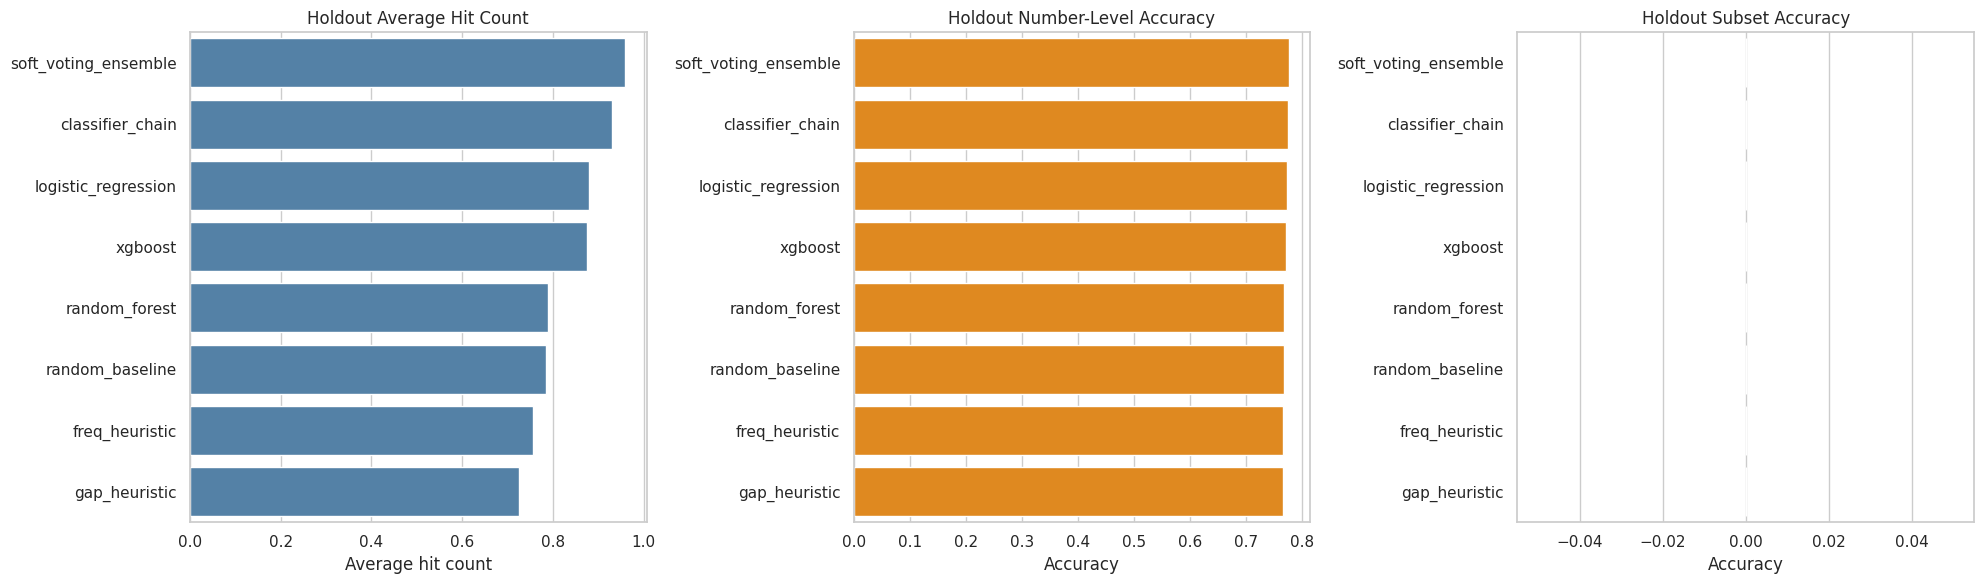

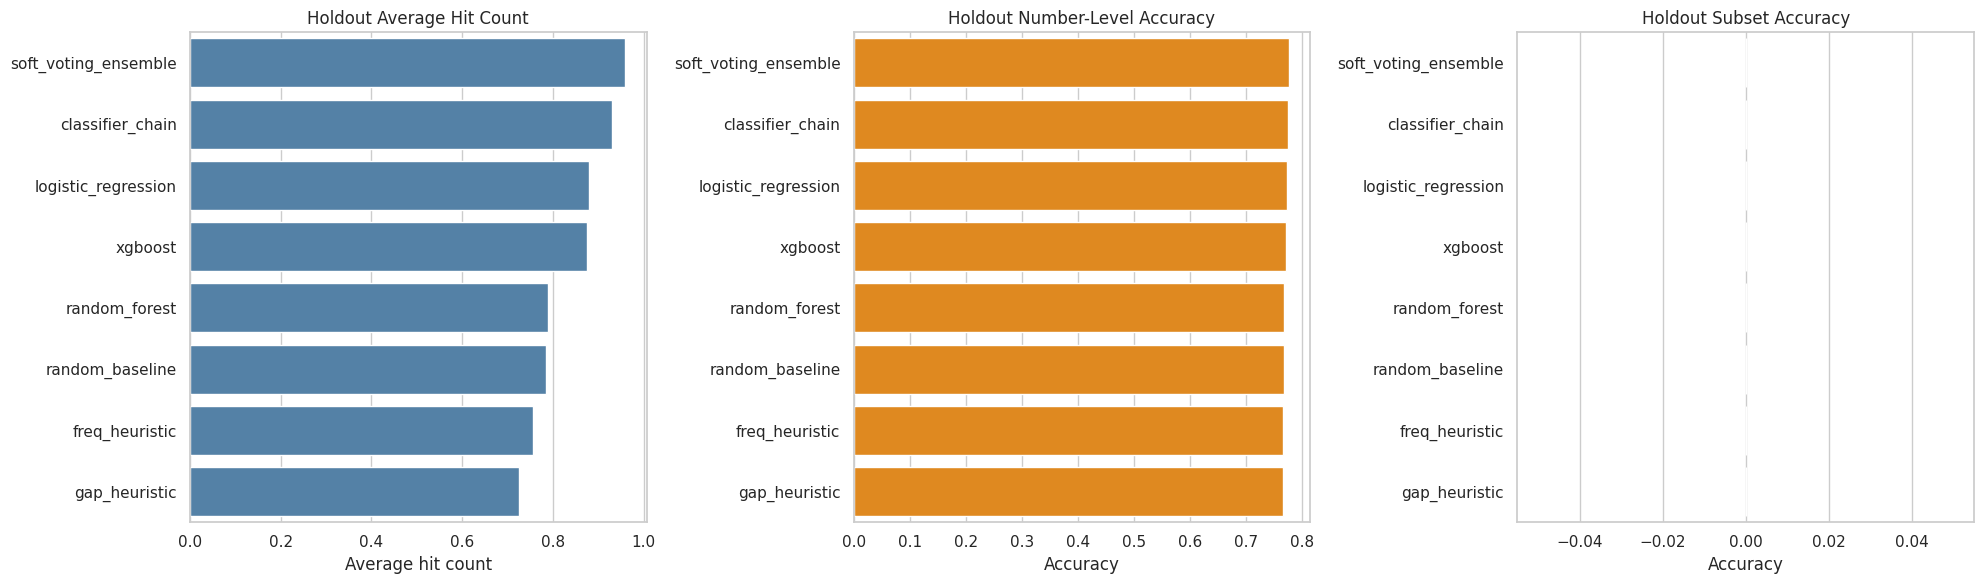

In [4]:
plot_holdout_metric_bars(holdout_summary)

### 5. Draw-Level Hit Distribution

This view shows how the per-draw hit counts are distributed across models.

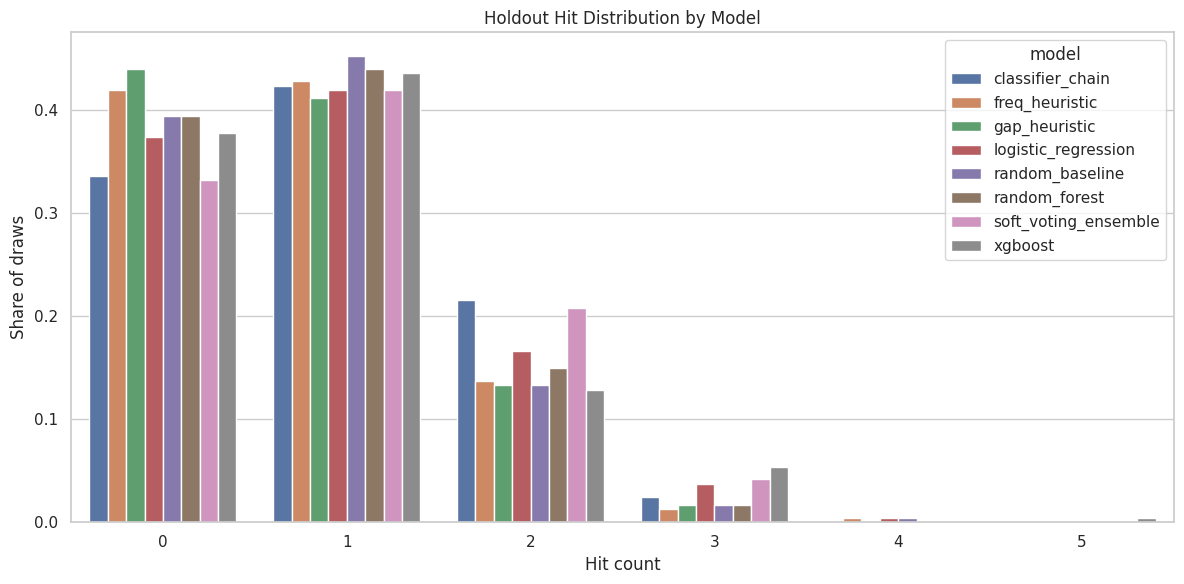

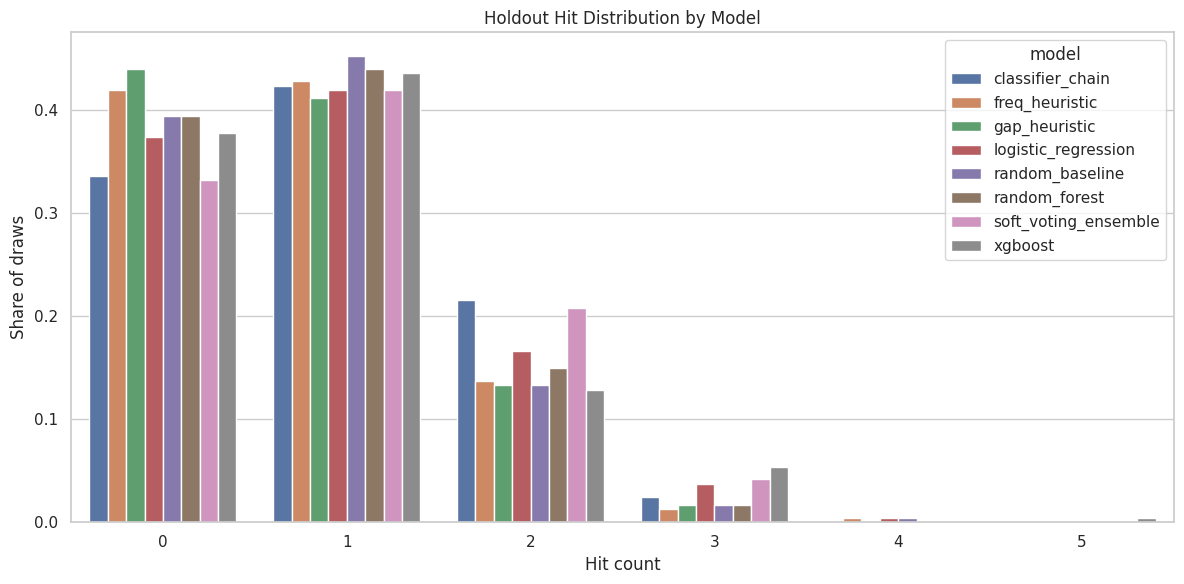

In [5]:
hit_distribution = (
    holdout_draw_results.groupby(["model", "hit_count"]).size().reset_index(name="count")
)
hit_distribution["share"] = hit_distribution.groupby("model")["count"].transform(lambda s: s / s.sum())

plot_hit_distribution(hit_distribution)

### 6. Rolling Backtest Summary

These results average performance across multiple expanding-window backtest folds.

In [6]:
backtest_summary.sort_values("mean_avg_hit", ascending=False)

,model,folds,mean_subset_accuracy,mean_number_level_accuracy,mean_avg_hit,mean_precision_at_6,mean_recall_at_6,mean_brier_score,std_avg_hit
0,soft_voting_ensemble,20,0.0,0.771630,0.861667,0.143611,0.143611,0.194219,0.141948
1,random_baseline,20,0.0,0.771556,0.860000,0.143333,0.143333,NaN,0.155447
2,logistic_regression,20,0.0,0.770667,0.840000,0.140000,0.140000,0.307935,0.140425
3,gap_heuristic,20,0.0,0.769259,0.808333,0.134722,0.134722,NaN,0.177664
4,freq_heuristic,20,0.0,0.767852,0.776667,0.129444,0.129444,NaN,0.139799


### 7. Rolling Backtest Visualizations

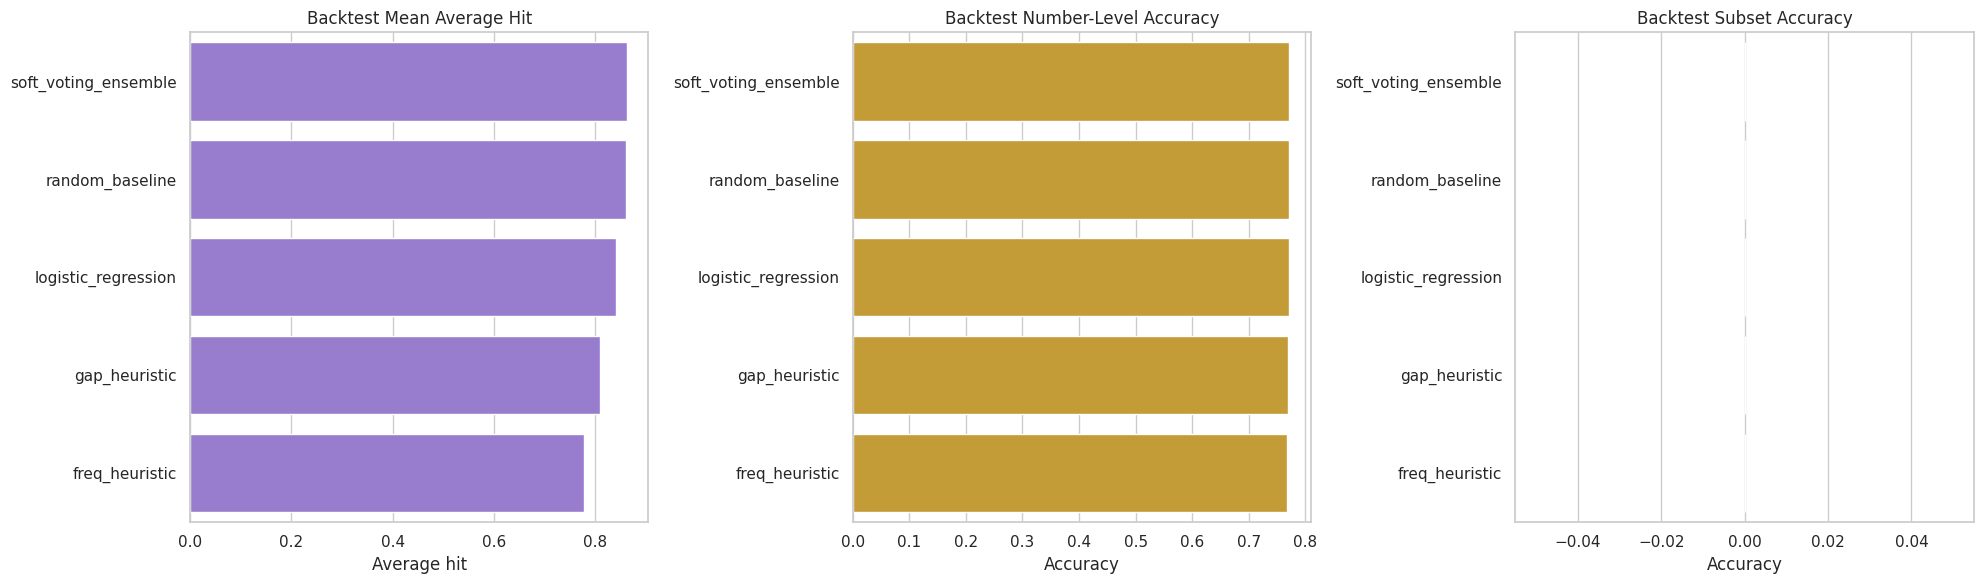

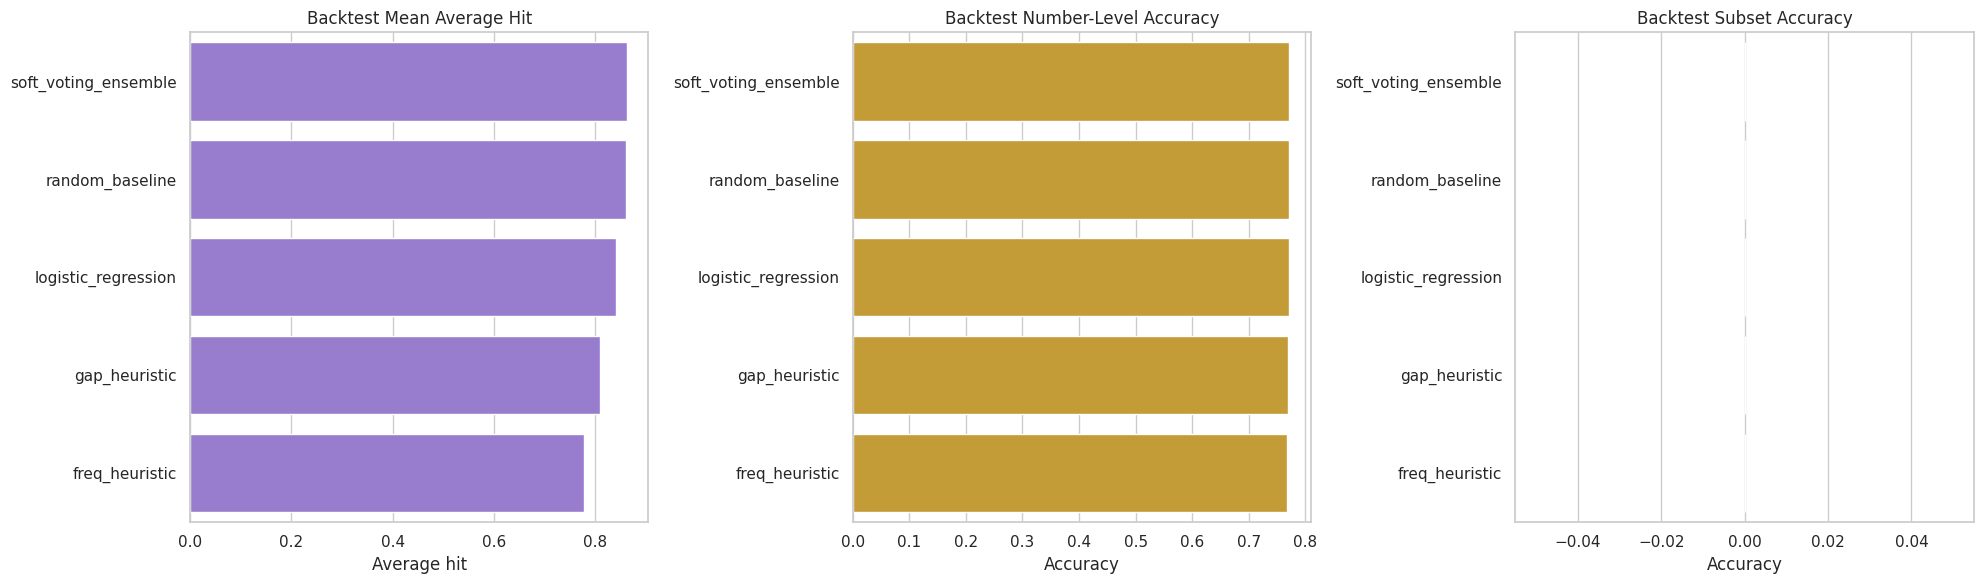

In [7]:
plot_backtest_metric_bars(backtest_summary)

### 8. Backtest Stability Over Folds

This line plot helps check whether model performance is stable or highly variable across time slices.

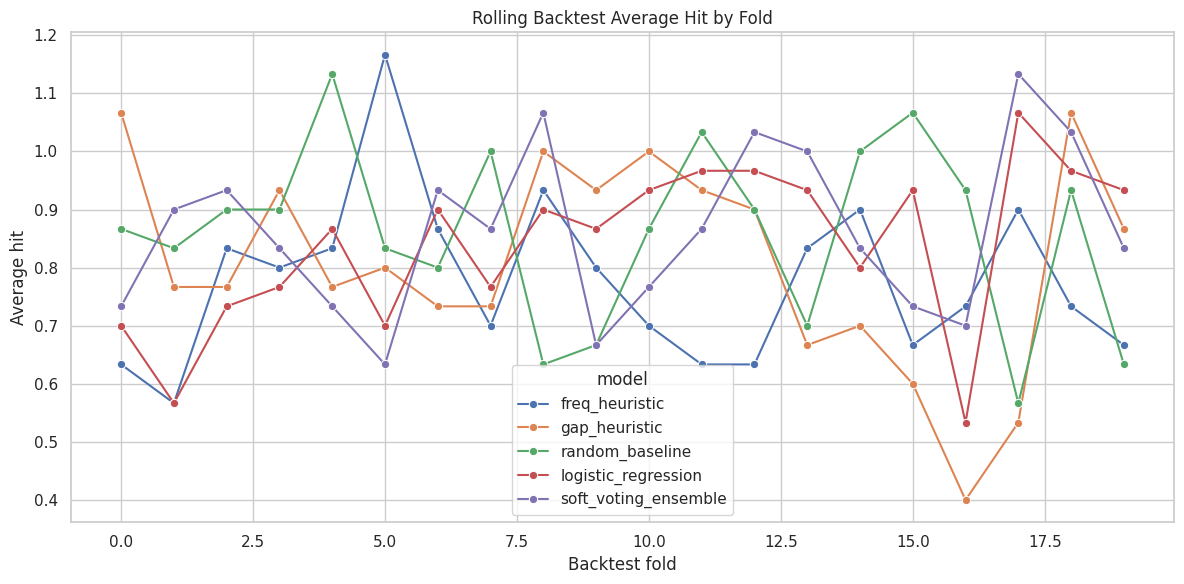

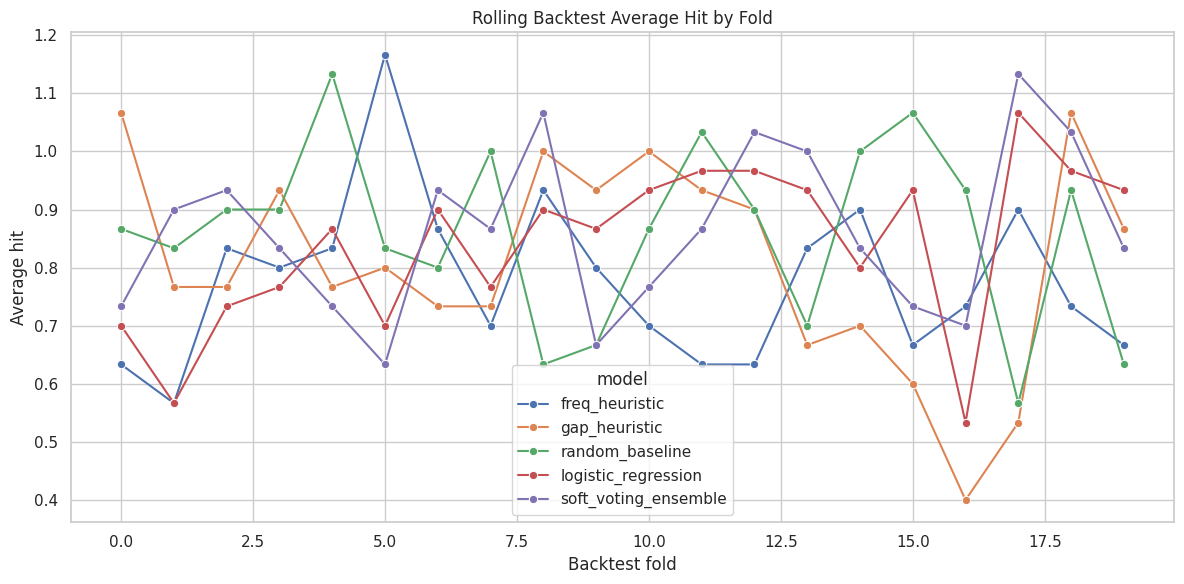

In [8]:
plot_backtest_stability(backtest_results)

### 9. Summary

This notebook evaluates the outputs produced by Notebook 05 without retraining the models.

The main outputs are:
- Holdout accuracy table for every model
- Draw-level hit distribution comparison
- Rolling backtest summary and stability trend

Probability calibration diagnostics are handled in Notebook 10, where the richer model-family experiments still have access to model-level probability outputs.


### Report Export


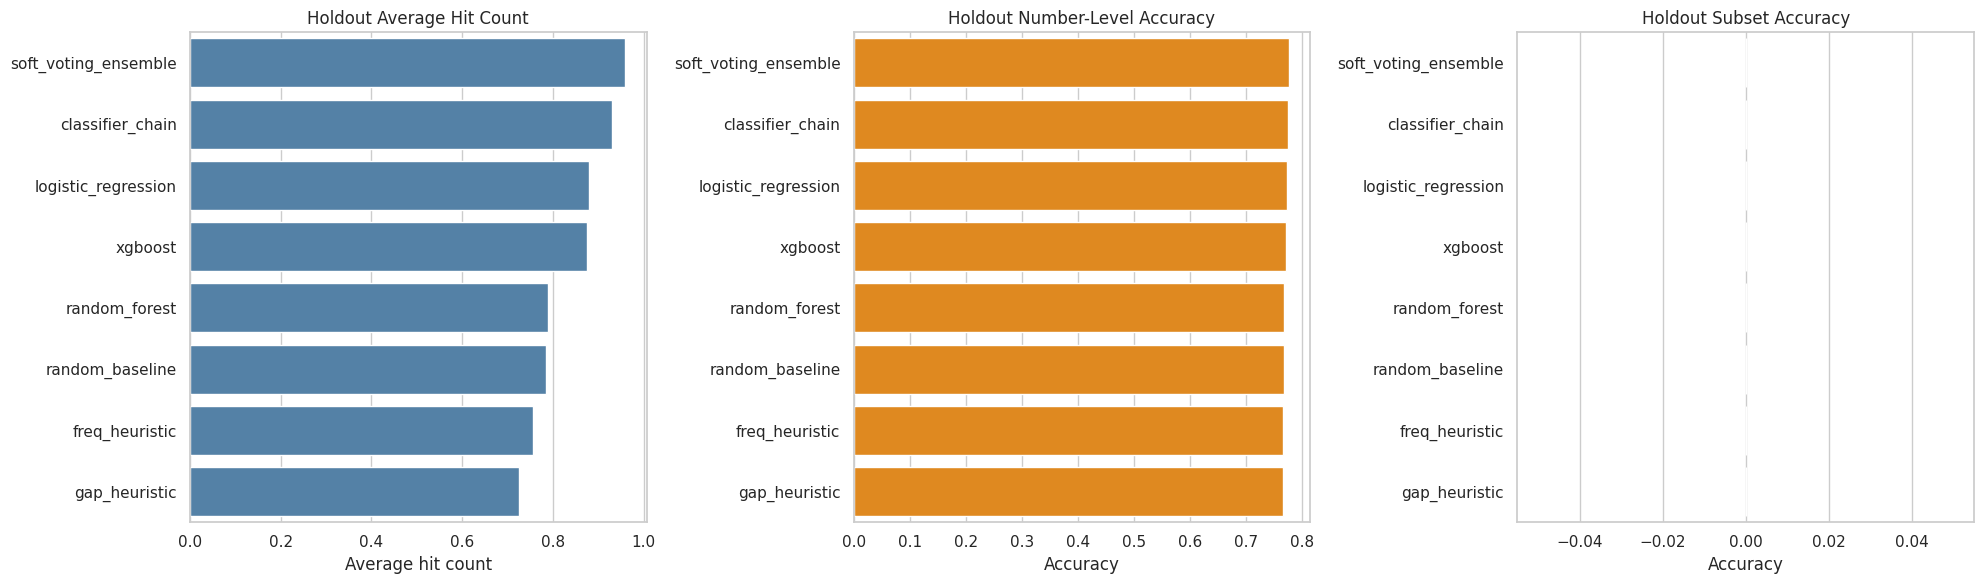

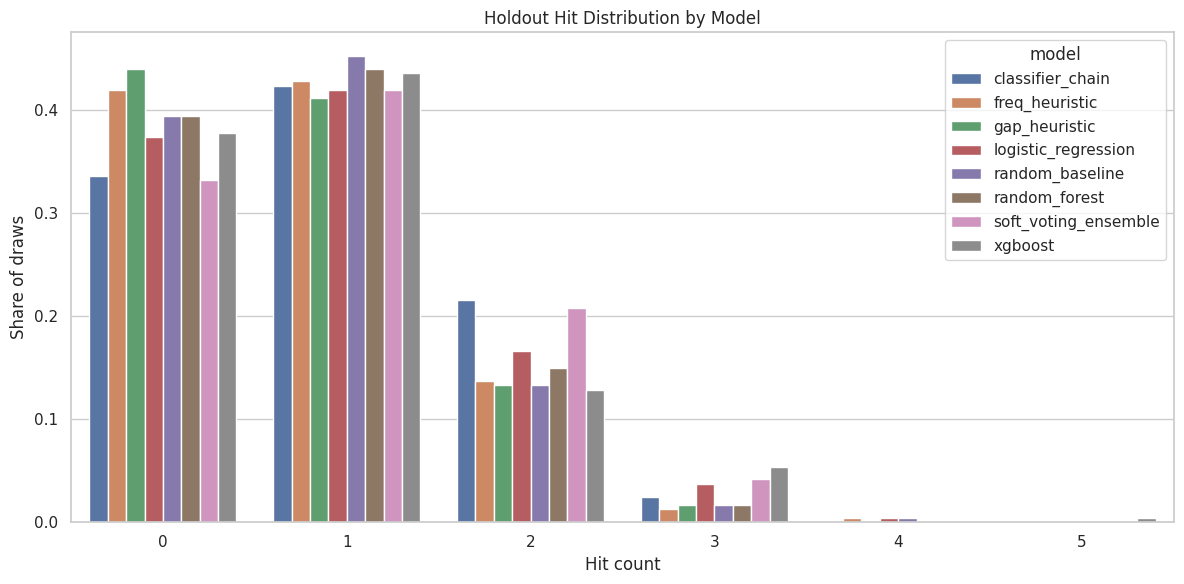

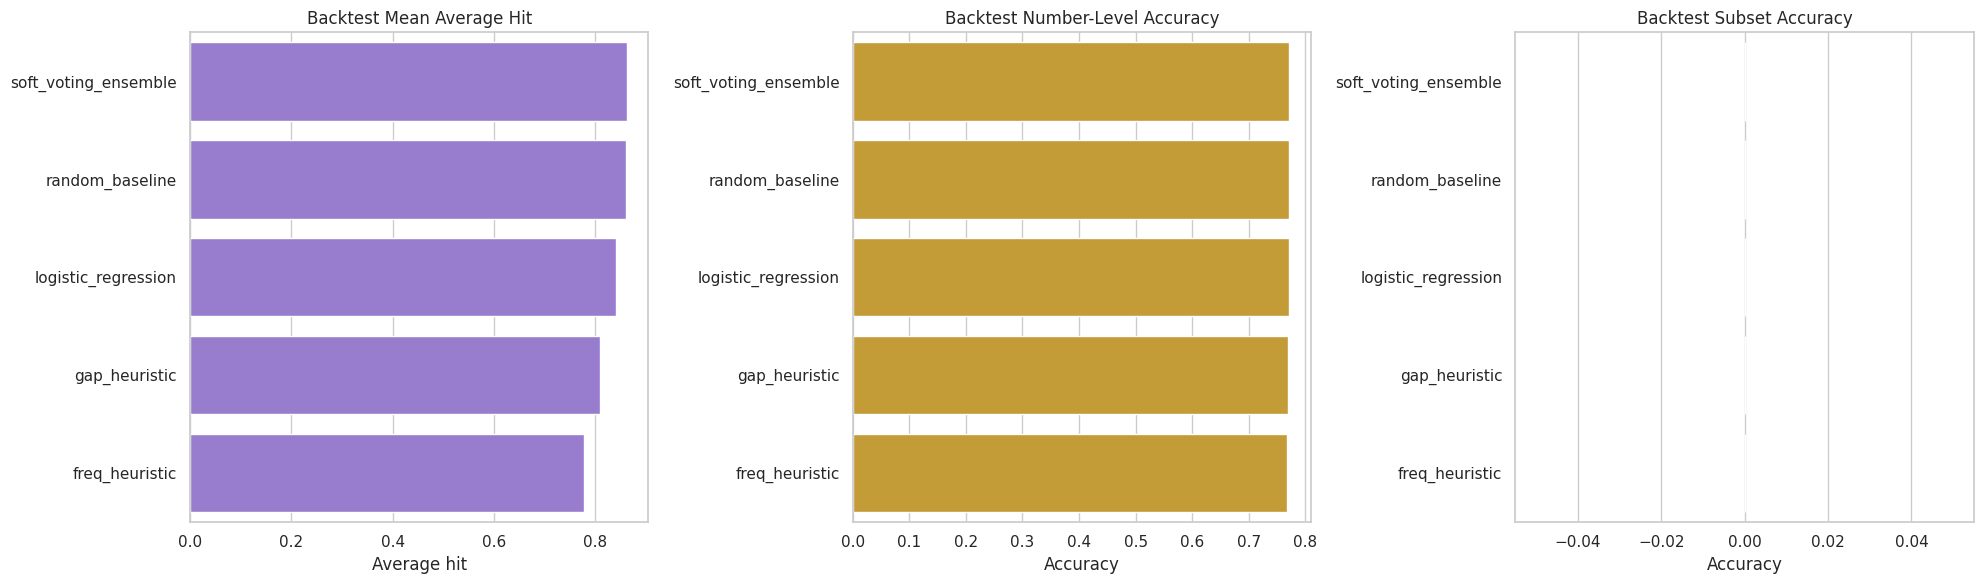

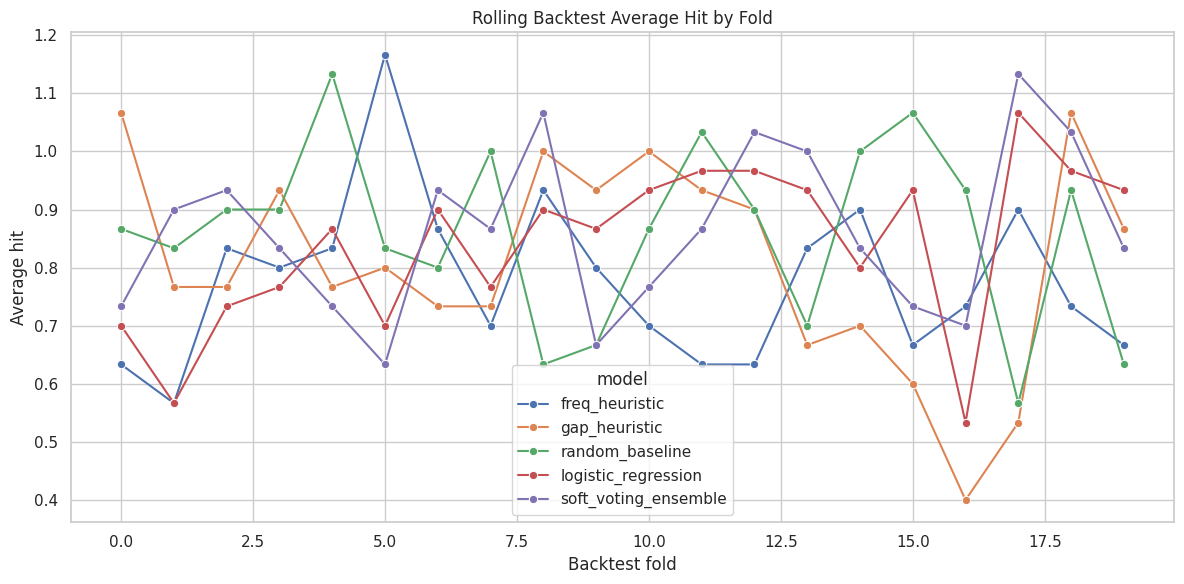

Saved evaluation report artifacts.


In [9]:
# Save key evaluation figures and tables for the final report
fig = plot_holdout_metric_bars(holdout_summary)
save_report_figure(fig, "fig_07_holdout_model_comparison.png")
plt.close(fig)

fig = plot_hit_distribution(hit_distribution)
save_report_figure(fig, "fig_08_draw_level_hit_distribution.png")
plt.close(fig)

fig = plot_backtest_metric_bars(backtest_summary)
save_report_figure(fig, "fig_09_backtest_model_comparison.png")
plt.close(fig)

fig = plot_backtest_stability(backtest_results)
save_report_figure(fig, "fig_10_backtest_trend.png")
plt.close(fig)

save_report_table(holdout_summary, "table_05_holdout_summary.csv")
save_report_table(backtest_summary, "table_06_backtest_summary.csv")
save_report_table(holdout_draw_results, "table_07_draw_level_results.csv")
save_report_table(pd.DataFrame([run_metadata]), "table_08_run_metadata.csv")
print("Saved evaluation report artifacts.")
